# Bài thực hành 4: So sánh ảnh bằng Wavelet Hash

**Chương 3 – Phần 1: Phát hiện đặc trưng và đối sánh ảnh**

Notebook này chứa toàn bộ mã nguồn, không cần file `.py` bên ngoài.

Luồng:

`Hai thư mục ảnh → đọc ảnh → Wavelet Hash → Hamming → chọn ngưỡng → đánh giá → tìm ảnh gần nhất`

Mỗi mục đều ghi rõ **Input**, **Output** và cách đọc kết quả. Chạy lần lượt bằng **Run All**.


## 1. Chuẩn bị ảnh đầu vào

### Input

```text
image/
├── tuong_tu/          # Ít nhất 3 ảnh của CÙNG một đối tượng hoặc cảnh
│   ├── anh_goc.jpg
│   ├── anh_sang_hon.jpg
│   └── anh_xoay.jpg
└── khong_tuong_tu/    # Ít nhất 1 ảnh KHÁC đối tượng hoặc cảnh
    ├── anh_khac_1.jpg
    └── anh_khac_2.jpg
```

Tên file tùy ý. Định dạng hỗ trợ: `.jpg`, `.jpeg`, `.png`, `.bmp`, `.tif`, `.tiff`, `.webp`.

### Output

Ô mã bên dưới in số ảnh đọc được và hiển thị toàn bộ ảnh. Tiêu đề **xanh** là ảnh tương tự, **đỏ** là ảnh không tương tự.


[MÔI TRƯỜNG] Python: e:\python\python.exe
[MÔI TRƯỜNG] PyWavelets: 1.8.0
[INPUT] Thư mục tương tự      : E:\xulianh\Elearning\CHUONG_3\PHAN_1\image\tuong_tu
[INPUT] Thư mục không tương tự: E:\xulianh\Elearning\CHUONG_3\PHAN_1\image\khong_tuong_tu
[OUTPUT] Đọc được 5 ảnh tương tự và 3 ảnh không tương tự.
[NHẬN XÉT] Kiểm tra bằng mắt xem ảnh đã được đặt đúng nhóm trước khi học tiếp.


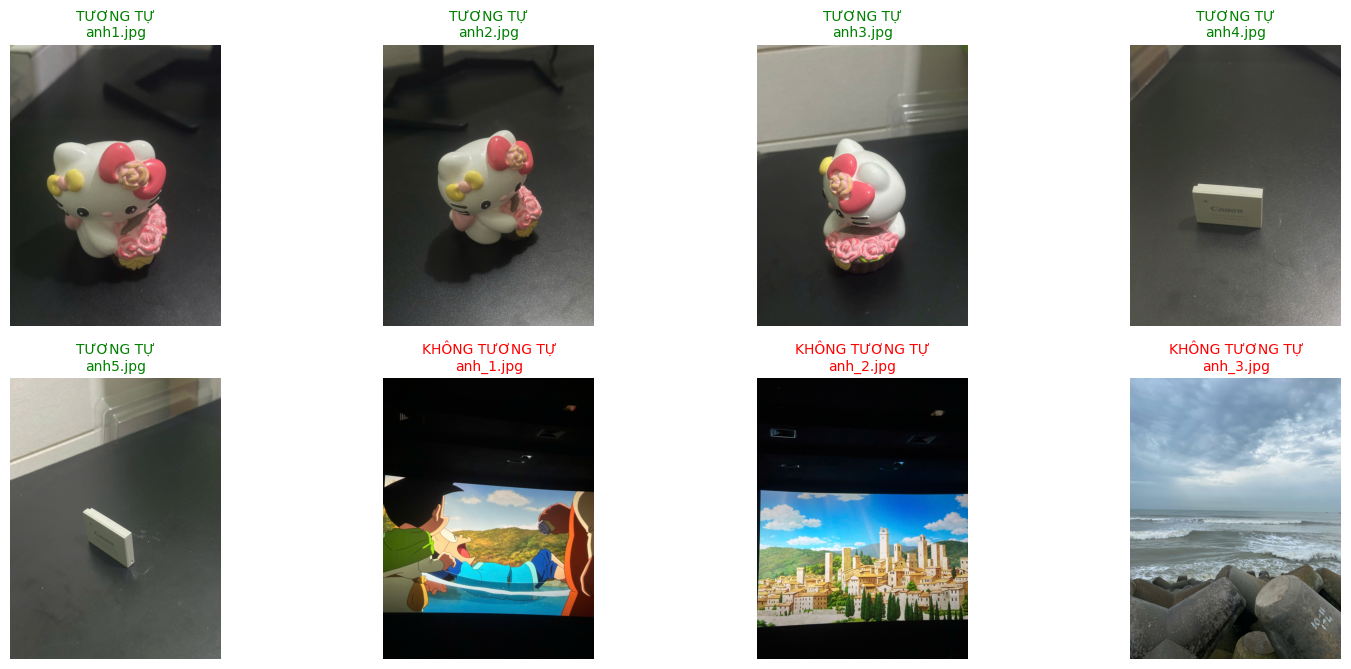

In [16]:
# ============================================================
# MỤC 1: ĐỌC VÀ KIỂM TRA DỮ LIỆU ẢNH
# Input : hai thư mục image/tuong_tu và image/khong_tuong_tu
# Output: biến images chứa ảnh RGB và labels_by_name chứa nhãn nhóm
# ============================================================
from pathlib import Path
import itertools
import subprocess
import sys
# Hàm cv2
import cv2
# Hàm matplotlib hiển thị ảnh
import matplotlib.pyplot as plt
# Hàm numpy 
import numpy as np
# PyWavelets được cài vào đúng môi trường của kernel Jupyter nếu còn thiếu.
try:
    import pywt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "PyWavelets"])
    import pywt
print(f"[MÔI TRƯỜNG] Python: {sys.executable}")
print(f"[MÔI TRƯỜNG] PyWavelets: {pywt.__version__}")

ROOT = Path.cwd()
if not (ROOT / "image").exists():
    candidate = ROOT / "CHUONG_3" / "PHAN_1"
    if candidate.exists():
        ROOT = candidate

SIMILAR_DIR = ROOT / "image" / "tuong_tu"
DISSIMILAR_DIR = ROOT / "image" / "khong_tuong_tu"
OUTPUT_DIR = ROOT / "outputs"
SIMILAR_DIR.mkdir(parents=True, exist_ok=True)
DISSIMILAR_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
RNG = np.random.default_rng(42)
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 10})


def list_images(folder):
    return sorted(path for path in folder.iterdir() if path.is_file() and path.suffix.lower() in EXTENSIONS)


def read_rgb(path):
    image = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if image is None:
        raise ValueError(f"Không đọc được ảnh: {path}")
    if image.ndim == 2:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    if image.shape[2] == 4:
        return cv2.cvtColor(image, cv2.COLOR_BGRA2RGBA)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


similar_paths = list_images(SIMILAR_DIR)
dissimilar_paths = list_images(DISSIMILAR_DIR)
if len(similar_paths) < 3 or len(dissimilar_paths) < 1:
    raise ValueError(
        "Thiếu dữ liệu: hãy đặt ít nhất 3 ảnh vào image/tuong_tu "
        "và ít nhất 1 ảnh vào image/khong_tuong_tu."
    )

images = {path.name: read_rgb(path) for path in similar_paths + dissimilar_paths}
labels_by_name = {path.name: 1 for path in similar_paths} | {path.name: 0 for path in dissimilar_paths}

print("[INPUT] Thư mục tương tự      :", SIMILAR_DIR.resolve())
print("[INPUT] Thư mục không tương tự:", DISSIMILAR_DIR.resolve())
print(f"[OUTPUT] Đọc được {len(similar_paths)} ảnh tương tự và {len(dissimilar_paths)} ảnh không tương tự.")

cols = min(4, len(images))
rows = int(np.ceil(len(images) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.4 * rows), squeeze=False)
for ax in axes.flat:
    ax.axis("off")
for ax, (name, image) in zip(axes.flat, images.items()):
    is_similar = labels_by_name[name] == 1
    ax.imshow(image)
    ax.set_title(("TƯƠNG TỰ\n" if is_similar else "KHÔNG TƯƠNG TỰ\n") + name,
                 color="green" if is_similar else "red")
    ax.axis("off")
plt.tight_layout()
print("[NHẬN XÉT] Kiểm tra bằng mắt xem ảnh đã được đặt đúng nhóm trước khi học tiếp.")


## 2. Các hàm Wavelet Hash

### Input

Một ảnh màu/xám và các tham số `wavelet`, `level`, `hash_size`.

### Output

- `wavelet_hash(...)`: mã nhị phân dài `hash_size²` bit.
- `hamming_distance(...)`: số bit khác nhau giữa hai mã; **càng nhỏ càng giống**.
- Các hàm đánh giá: accuracy, sensitivity, specificity, precision và ROC/AUC.


In [17]:
# ============================================================
# MỤC 2: CÁC HÀM CỐT LÕI CỦA WAVELET HASH
# Quy trình: ảnh -> ảnh xám -> ma trận wavelet LL -> lượng tử hóa -> hash
# ============================================================


def to_gray(image, image_size):
    """Đổi ảnh RGB/RGBA sang ảnh xám vuông, giá trị chuẩn hóa trong [0, 1]."""
    data = np.asarray(image)

    # Wavelet xử lý trên một kênh nên ảnh màu phải được đổi sang ảnh xám.
    if data.ndim == 3:
        conversion = cv2.COLOR_RGBA2GRAY if data.shape[2] == 4 else cv2.COLOR_RGB2GRAY
        data = cv2.cvtColor(data, conversion)
    elif data.ndim != 2:
        raise ValueError("Ảnh phải có dạng HxW, HxWx3 hoặc HxWx4")

    # Chuẩn hóa kích thước để mọi ảnh tạo ra mã băm có cùng số bit.
    data = cv2.resize(data, (image_size, image_size), interpolation=cv2.INTER_AREA)
    data = data.astype(np.float32)
    if data.max() > 1.0:
        data /= 255.0
    return np.clip(data, 0.0, 1.0)


def wavelet_hash(image, wavelet="db4", level=2, hash_size=8):
    """Tạo mã Wavelet Hash nhị phân gồm hash_size² bit."""
    if hash_size < 2 or level < 1:
        raise ValueError("hash_size phải >= 2 và level phải >= 1")

    # DWT level lần làm kích thước giảm 2^level lần.
    image_size = hash_size * (2 ** level)
    gray = to_gray(image, image_size)
    max_level = pywt.dwtn_max_level(gray.shape, wavelet)
    if level > max_level:
        raise ValueError(f"level={level} quá lớn; mức tối đa là {max_level}")

    # wavedec2 trả về ma trận xấp xỉ LL và các ma trận chi tiết.
    # Wavelet Hash chỉ dùng LL vì LL giữ hình dáng/cấu trúc tổng quát của ảnh.
    approximation_ll = pywt.wavedec2(gray, wavelet=wavelet, level=level)[0]
    low_frequency = cv2.resize(
        approximation_ll, (hash_size, hash_size), interpolation=cv2.INTER_AREA
    )

    # Lượng tử hóa: hệ số lớn hơn trung vị thành 1, còn lại thành 0.
    # Kết quả 8 x 8 được trải phẳng thành mã băm 64 bit.
    threshold = np.median(low_frequency)
    return (low_frequency > threshold).reshape(-1)


def hamming_distance(hash1, hash2):
    """Đếm số vị trí bit khác nhau; khoảng cách nhỏ nghĩa là ảnh giống nhau hơn."""
    a = np.asarray(hash1, dtype=bool).reshape(-1)
    b = np.asarray(hash2, dtype=bool).reshape(-1)
    if a.shape != b.shape:
        raise ValueError("Hai mã băm phải có cùng độ dài")
    return int(np.count_nonzero(a != b))


def hash_to_hex(hash_code):
    """Đổi chuỗi bit sang hệ 16 để hiển thị mã băm ngắn gọn trên console."""
    bits = np.asarray(hash_code, dtype=np.uint8).reshape(-1)
    if (-bits.size) % 4:
        bits = np.pad(bits, (0, (-bits.size) % 4))
    return "".join(f"{int(''.join(map(str, nibble)), 2):x}" for nibble in bits.reshape(-1, 4))


def classification_metrics(labels, predictions):
    """Tính confusion matrix và bốn chỉ số đánh giá được yêu cầu."""
    y = np.asarray(labels, dtype=int)       # Nhãn thật: 1 tương tự, 0 không tương tự
    p = np.asarray(predictions, dtype=int)  # Nhãn do thuật toán dự đoán

    # TP/TN là dự đoán đúng; FP/FN là hai loại dự đoán sai.
    tp = int(np.sum((y == 1) & (p == 1)))
    tn = int(np.sum((y == 0) & (p == 0)))
    fp = int(np.sum((y == 0) & (p == 1)))
    fn = int(np.sum((y == 1) & (p == 0)))
    safe = lambda numerator, denominator: numerator / denominator if denominator else 0.0
    return {
        "accuracy": safe(tp + tn, len(y)),              # Tỷ lệ tất cả cặp đúng
        "sensitivity": safe(tp, tp + fn),               # Tỷ lệ cặp tương tự nhận đúng
        "specificity": safe(tn, tn + fp),               # Tỷ lệ cặp không tương tự nhận đúng
        "precision": safe(tp, tp + fp),                 # Độ tin cậy khi dự đoán tương tự
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
    }


def roc_curve_from_distances(labels, distances):
    """Quét mọi ngưỡng Hamming để tạo các điểm ROC và tính AUC."""
    y = np.asarray(labels, dtype=int)
    d = np.asarray(distances, dtype=float)
    thresholds = np.r_[-np.inf, np.unique(d), np.inf]
    points = []

    # Với mỗi ngưỡng: Hamming <= ngưỡng được dự đoán là tương tự.
    for threshold in thresholds:
        metric = classification_metrics(y, d <= threshold)
        false_positive_rate = 1 - metric["specificity"]
        true_positive_rate = metric["sensitivity"]
        points.append((false_positive_rate, true_positive_rate, threshold))

    points.sort(key=lambda item: (item[0], item[1]))
    fpr, tpr, ordered_thresholds = map(np.asarray, zip(*points))
    auc = float(np.trapezoid(tpr, fpr))
    return fpr, tpr, ordered_thresholds, auc


print("[OUTPUT] Đã nạp các hàm Wavelet Hash và đánh giá.")
print("[NHẬN XÉT] Các ô sau gọi trực tiếp các hàm này; không cần file Python bên ngoài.")


[OUTPUT] Đã nạp các hàm Wavelet Hash và đánh giá.
[NHẬN XÉT] Các ô sau gọi trực tiếp các hàm này; không cần file Python bên ngoài.


## 3. Quan sát biến đổi Wavelet 2D

### Input

Ảnh đầu tiên trong thư mục `tuong_tu`.

### Output

Ảnh xám và bốn dải `LL`, `LH`, `HL`, `HH`. `LL` giữ cấu trúc tổng quát; ba dải còn lại giữ chi tiết theo hướng.


[INPUT] Ảnh minh họa: anh1.jpg
[OUTPUT] Đã phân rã ảnh bằng wavelet db4 mức 1.
[NHẬN XÉT] Wavelet Hash dùng vùng tần số thấp LL vì vùng này ít nhạy với nhiễu nhỏ.


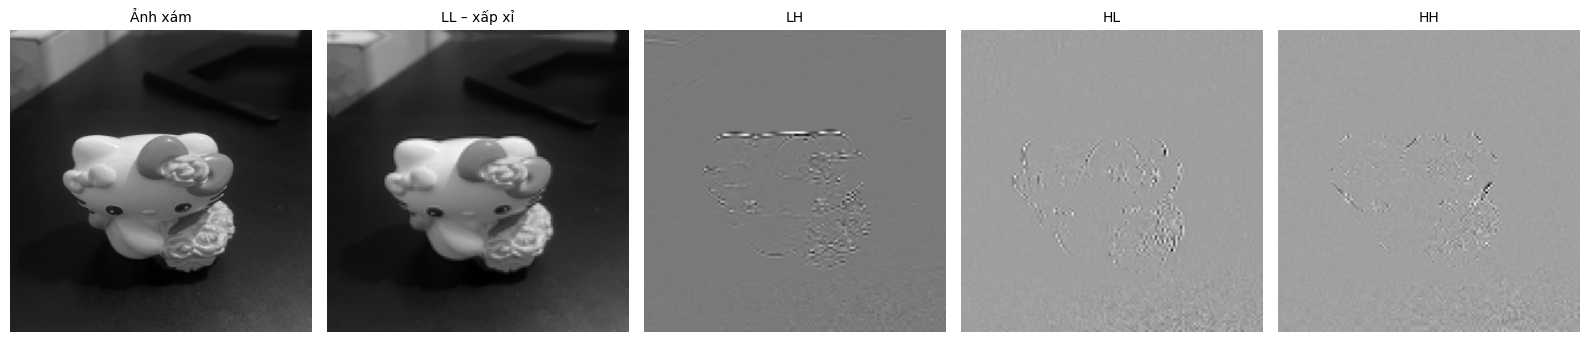

In [18]:
# MỤC 3: MINH HỌA MA TRẬN WAVELET CỦA MỘT ẢNH
# cA = LL; cH, cV, cD lần lượt là các thành phần chi tiết.
sample_name = similar_paths[0].name
sample_gray = to_gray(images[sample_name], 256)
cA, (cH, cV, cD) = pywt.dwt2(sample_gray, "db4")
bands = [sample_gray, cA, cH, cV, cD]
titles = ["Ảnh xám", "LL – xấp xỉ", "LH", "HL", "HH"]
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, band, title in zip(axes, bands, titles):
    ax.imshow(band, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
print("[INPUT] Ảnh minh họa:", sample_name)
print("[OUTPUT] Đã phân rã ảnh bằng wavelet db4 mức 1.")
print("[NHẬN XÉT] Wavelet Hash dùng vùng tần số thấp LL vì vùng này ít nhạy với nhiễu nhỏ.")


## 4. Tạo hash và khoảng cách Hamming

### Input

Tất cả ảnh trong hai thư mục.

### Output

Console in mã hash dạng hex và khoảng cách của từng cặp. Cặp trong `tuong_tu` có nhãn thật `1`; cặp giữa hai thư mục có nhãn thật `0`.


In [19]:
# MỤC 4: TẠO HASH VÀ TẠO CÁC CẶP CÓ NHÃN
# Cặp trong tuong_tu có nhãn 1; cặp chéo hai thư mục có nhãn 0.
hashes = {name: wavelet_hash(image) for name, image in images.items()}
print("[OUTPUT] Mã Wavelet Hash 64 bit:")
for name, value in hashes.items():
    print(f"  {name:30s} -> {hash_to_hex(value)}")

records = []
for left, right in itertools.combinations([path.name for path in similar_paths], 2):
    records.append((left, right, 1, hamming_distance(hashes[left], hashes[right])))
for left, right in itertools.product([path.name for path in similar_paths],
                                     [path.name for path in dissimilar_paths]):
    records.append((left, right, 0, hamming_distance(hashes[left], hashes[right])))

print("\n[OUTPUT] Khoảng cách từng cặp (nhãn 1 = tương tự, 0 = không tương tự):")
for left, right, label, distance in records:
    print(f"  nhãn={label} | Hamming={distance:2d} | {left} <-> {right}")
print("[NHẬN XÉT] Mong đợi: cặp nhãn 1 có Hamming nhỏ hơn cặp nhãn 0.")


[OUTPUT] Mã Wavelet Hash 64 bit:
  anh1.jpg                       -> f8f8f8f01c1e0707
  anh2.jpg                       -> e121e1011f0f0fff
  anh3.jpg                       -> fefefefe0c0c0000
  anh4.jpg                       -> e0a0e0000f0fffff
  anh5.jpg                       -> fdfcfff8f8000001
  anh_1.jpg                      -> 006000eeffffff00
  anh_2.jpg                      -> 000200c0fffffff8
  anh_3.jpg                      -> fbd3f9ff5f000000

[OUTPUT] Khoảng cách từng cặp (nhãn 1 = tương tự, 0 = không tương tự):
  nhãn=1 | Hamming=26 | anh1.jpg <-> anh2.jpg
  nhãn=1 | Hamming=18 | anh1.jpg <-> anh3.jpg
  nhãn=1 | Hamming=26 | anh1.jpg <-> anh4.jpg
  nhãn=1 | Hamming=20 | anh1.jpg <-> anh5.jpg
  nhãn=1 | Hamming=42 | anh2.jpg <-> anh3.jpg
  nhãn=1 | Hamming=10 | anh2.jpg <-> anh4.jpg
  nhãn=1 | Hamming=40 | anh2.jpg <-> anh5.jpg
  nhãn=1 | Hamming=40 | anh3.jpg <-> anh4.jpg
  nhãn=1 | Hamming=14 | anh3.jpg <-> anh5.jpg
  nhãn=1 | Hamming=44 | anh4.jpg <-> anh5.jpg
  nhãn=0 | 

## 5. Chia validation/test và chọn ngưỡng

### Input

Các cặp ảnh và khoảng cách Hamming ở mục 4.

### Output

- **Validation** dùng để chọn ngưỡng có balanced accuracy cao nhất.
- **Test** được giữ riêng để đánh giá cuối.

Quy tắc dự đoán: `Hamming <= ngưỡng` thì hai ảnh được xem là tương tự.


[INPUT] Validation: 12 cặp | Test: 13 cặp
[OUTPUT] Ngưỡng tốt nhất: 40
[OUTPUT] Balanced accuracy validation: 0.714
[NHẬN XÉT] Đường đỏ là ngưỡng sẽ dùng cho tập test; không chọn lại ngưỡng bằng test.


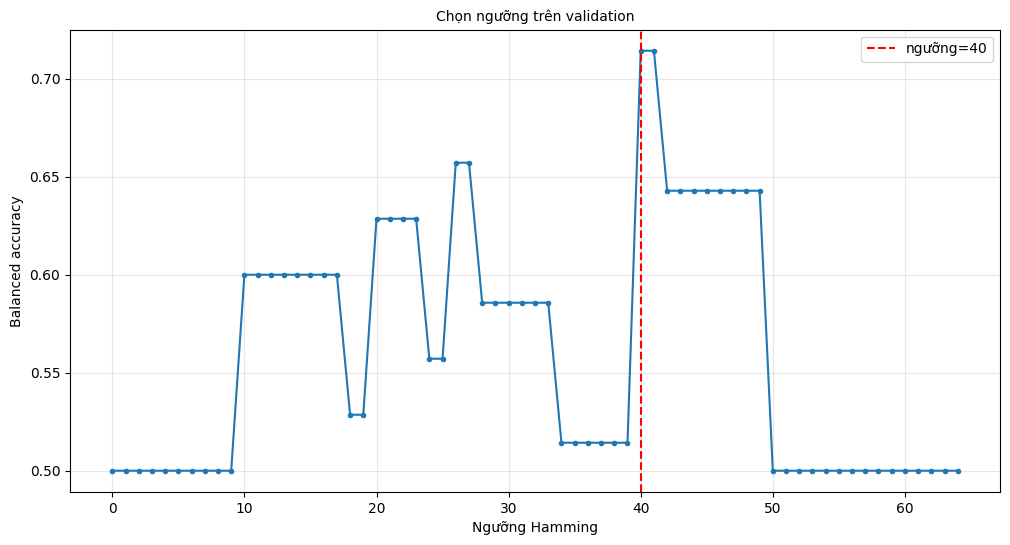

In [20]:
# MỤC 5: CHIA DỮ LIỆU VÀ CHỌN NGƯỠNG
# Chỉ validation được dùng chọn ngưỡng; test được giữ lại để đánh giá công bằng.
positive = [record for record in records if record[2] == 1]
negative = [record for record in records if record[2] == 0]
if len(positive) < 2 or len(negative) < 2:
    raise ValueError("Cần ít nhất 2 cặp mỗi lớp để chia validation/test.")
RNG.shuffle(positive)
RNG.shuffle(negative)


def split_class(items):
    cut = max(1, min(len(items) - 1, len(items) // 2))
    return items[:cut], items[cut:]


val_pos, test_pos = split_class(positive)
val_neg, test_neg = split_class(negative)
validation = val_pos + val_neg
test = test_pos + test_neg

val_labels = np.array([record[2] for record in validation])
val_distances = np.array([record[3] for record in validation])
candidate_thresholds = np.arange(65)
scores = []
for threshold in candidate_thresholds:
    metric = classification_metrics(val_labels, val_distances <= threshold)
    scores.append((metric["sensitivity"] + metric["specificity"]) / 2)
best_threshold = int(candidate_thresholds[np.argmax(scores)])

print(f"[INPUT] Validation: {len(validation)} cặp | Test: {len(test)} cặp")
print("[OUTPUT] Ngưỡng tốt nhất:", best_threshold)
print("[OUTPUT] Balanced accuracy validation:", f"{max(scores):.3f}")
plt.plot(candidate_thresholds, scores, marker=".")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"ngưỡng={best_threshold}")
plt.xlabel("Ngưỡng Hamming")
plt.ylabel("Balanced accuracy")
plt.title("Chọn ngưỡng trên validation")
plt.grid(alpha=.3)
plt.legend()
print("[NHẬN XÉT] Đường đỏ là ngưỡng sẽ dùng cho tập test; không chọn lại ngưỡng bằng test.")


## 6. Đánh giá trên tập test

### Input

Tập test chưa dùng để chọn ngưỡng và `best_threshold` từ validation.

### Output

Console in Accuracy, Sensitivity, Specificity, Precision; hình bên dưới gồm histogram khoảng cách, ROC và ma trận nhầm lẫn.


[OUTPUT] Accuracy    : 0.308
[OUTPUT] Sensitivity : 0.600
[OUTPUT] Specificity : 0.125
[OUTPUT] Precision   : 0.300
[OUTPUT] TP=3, TN=1, FP=7, FN=2
[OUTPUT] AUC: 0.537
[OUTPUT] Đã lưu hình: e:\xulianh\Elearning\CHUONG_3\PHAN_1\outputs\wavelet_hash_evaluation.png
[NHẬN XÉT] Kết quả tốt khi hai histogram tách nhau, Accuracy/AUC gần 1 và FP/FN thấp.


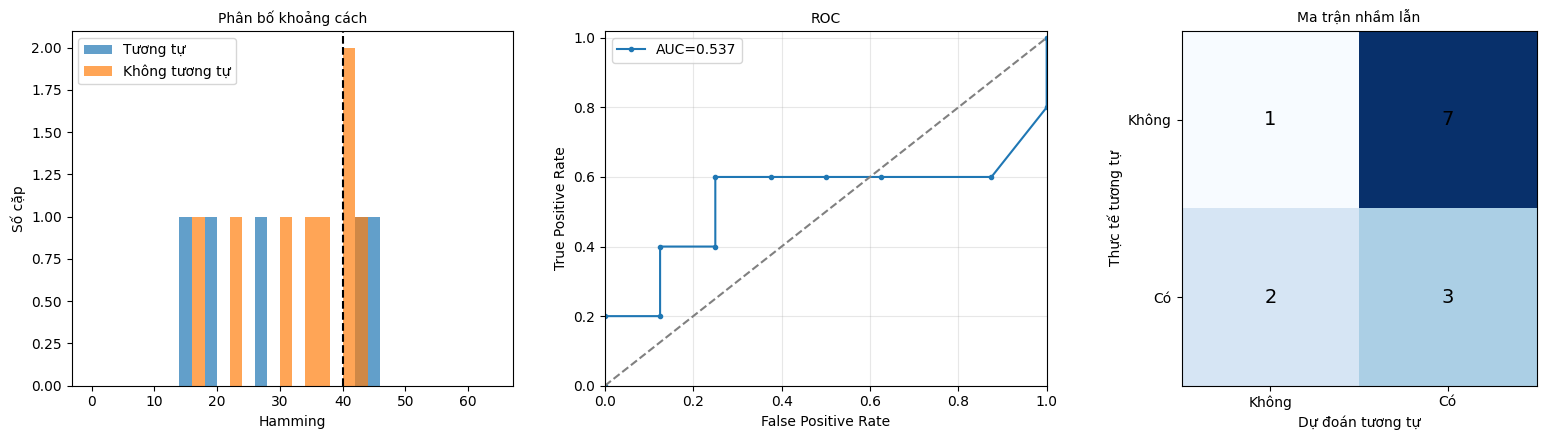

In [21]:
# MỤC 6: ĐÁNH GIÁ ĐẦY ĐỦ TRÊN TEST
# Kết quả gồm Accuracy, Sensitivity, Specificity, Precision, ROC/AUC và confusion matrix.
test_labels = np.array([record[2] for record in test])
test_distances = np.array([record[3] for record in test])
test_predictions = (test_distances <= best_threshold).astype(int)
metric = classification_metrics(test_labels, test_predictions)

print(f"[OUTPUT] Accuracy    : {metric['accuracy']:.3f}")
print(f"[OUTPUT] Sensitivity : {metric['sensitivity']:.3f}")
print(f"[OUTPUT] Specificity : {metric['specificity']:.3f}")
print(f"[OUTPUT] Precision   : {metric['precision']:.3f}")
print(f"[OUTPUT] TP={metric['tp']}, TN={metric['tn']}, FP={metric['fp']}, FN={metric['fn']}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(test_distances[test_labels == 1], bins=np.arange(0, 66, 2), alpha=.7, label="Tương tự")
axes[0].hist(test_distances[test_labels == 0], bins=np.arange(0, 66, 2), alpha=.7, label="Không tương tự")
axes[0].axvline(best_threshold, color="black", linestyle="--")
axes[0].set(xlabel="Hamming", ylabel="Số cặp", title="Phân bố khoảng cách")
axes[0].legend()

fpr, tpr, _, auc = roc_curve_from_distances(test_labels, test_distances)
axes[1].plot(fpr, tpr, marker=".", label=f"AUC={auc:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC", xlim=(0, 1), ylim=(0, 1.02))
axes[1].grid(alpha=.3)
axes[1].legend()

cm = np.array([[metric["tn"], metric["fp"]], [metric["fn"], metric["tp"]]])
axes[2].imshow(cm, cmap="Blues")
for row in range(2):
    for col in range(2):
        axes[2].text(col, row, cm[row, col], ha="center", va="center", fontsize=14)
axes[2].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Không", "Có"], yticklabels=["Không", "Có"],
            xlabel="Dự đoán tương tự", ylabel="Thực tế tương tự", title="Ma trận nhầm lẫn")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wavelet_hash_evaluation.png", dpi=150, bbox_inches="tight")
print(f"[OUTPUT] AUC: {auc:.3f}")
print("[OUTPUT] Đã lưu hình:", OUTPUT_DIR / "wavelet_hash_evaluation.png")
print("[NHẬN XÉT] Kết quả tốt khi hai histogram tách nhau, Accuracy/AUC gần 1 và FP/FN thấp.")


## 7. Bài tập nâng cao: so sánh các phương pháp Wavelet Hash

### Input

Cùng tập validation/test đã tạo ở mục 5 và bốn họ wavelet: `haar`, `db2`, `db4`, `sym4`.

### Xử lý

Với mỗi họ wavelet, notebook tạo lại hash, chọn ngưỡng riêng trên validation rồi đo Accuracy và AUC trên cùng tập test. Nhờ dùng cùng dữ liệu, kết quả so sánh công bằng hơn.

### Output

Console in ngưỡng và các chỉ số của từng phương pháp; biểu đồ so sánh Accuracy và AUC. Phương pháp tốt hơn thường có hai cột cao hơn, nhưng kết luận chỉ có ý nghĩa trên tập ảnh đang dùng.


[OUTPUT] So sánh các phương pháp trên cùng tập test:
  haar  | ngưỡng=22 | Accuracy=0.385 | Sensitivity=0.000 | Specificity=0.625 | AUC=0.325
  db2   | ngưỡng=20 | Accuracy=0.692 | Sensitivity=0.400 | Specificity=0.875 | AUC=0.587
  db4   | ngưỡng=40 | Accuracy=0.308 | Sensitivity=0.600 | Specificity=0.125 | AUC=0.537
  sym4  | ngưỡng=16 | Accuracy=0.538 | Sensitivity=0.000 | Specificity=0.875 | AUC=0.537
[NHẬN XÉT] Trên tập ảnh hiện tại, db2 tốt nhất theo ưu tiên AUC rồi Accuracy.
[OUTPUT] Đã lưu hình: e:\xulianh\Elearning\CHUONG_3\PHAN_1\outputs\wavelet_methods_comparison.png


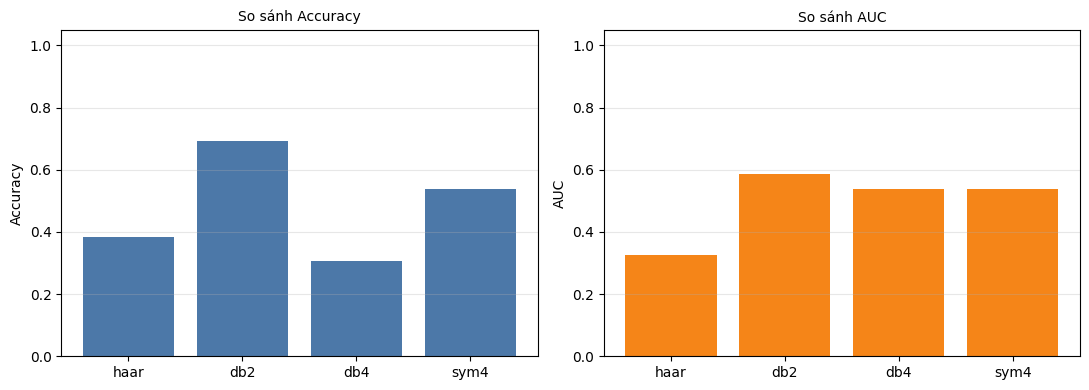

In [22]:
# ============================================================
# MỤC 7: KHẢO SÁT NHIỀU PHƯƠNG PHÁP WAVELET HASH
# Input : cùng các cặp validation/test, thay đổi duy nhất họ wavelet
# Output: threshold, Accuracy, Sensitivity, Specificity và AUC mỗi phương pháp
# ============================================================

wavelet_families = ["haar", "db2", "db4", "sym4"]
comparison = []

for family in wavelet_families:
    # Bước 1: tạo lại mã băm cho mọi ảnh bằng họ wavelet đang khảo sát.
    family_hashes = {
        name: wavelet_hash(image, wavelet=family, level=2, hash_size=8)
        for name, image in images.items()
    }

    # Bước 2: tính Hamming trên validation và chọn ngưỡng tốt nhất cho họ này.
    family_val_distances = np.array([
        hamming_distance(family_hashes[left], family_hashes[right])
        for left, right, _, _ in validation
    ])
    family_scores = []
    for threshold in candidate_thresholds:
        family_metric = classification_metrics(val_labels, family_val_distances <= threshold)
        family_scores.append((family_metric["sensitivity"] + family_metric["specificity"]) / 2)
    family_threshold = int(candidate_thresholds[np.argmax(family_scores)])

    # Bước 3: giữ nguyên ngưỡng vừa chọn và đánh giá trên test.
    family_test_distances = np.array([
        hamming_distance(family_hashes[left], family_hashes[right])
        for left, right, _, _ in test
    ])
    family_predictions = family_test_distances <= family_threshold
    family_metric = classification_metrics(test_labels, family_predictions)
    _, _, _, family_auc = roc_curve_from_distances(test_labels, family_test_distances)

    comparison.append({
        "wavelet": family,
        "threshold": family_threshold,
        "accuracy": family_metric["accuracy"],
        "sensitivity": family_metric["sensitivity"],
        "specificity": family_metric["specificity"],
        "auc": family_auc,
    })

print("[OUTPUT] So sánh các phương pháp trên cùng tập test:")
for result in comparison:
    print(
        f"  {result['wavelet']:5s} | ngưỡng={result['threshold']:2d} "
        f"| Accuracy={result['accuracy']:.3f} "
        f"| Sensitivity={result['sensitivity']:.3f} "
        f"| Specificity={result['specificity']:.3f} "
        f"| AUC={result['auc']:.3f}"
    )

# Hai biểu đồ dùng chung thang 0..1 để dễ so sánh trực quan.
names = [result["wavelet"] for result in comparison]
accuracies = [result["accuracy"] for result in comparison]
aucs = [result["auc"] for result in comparison]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(names, accuracies, color="#4c78a8")
axes[0].set(title="So sánh Accuracy", ylabel="Accuracy", ylim=(0, 1.05))
axes[0].grid(axis="y", alpha=.3)
axes[1].bar(names, aucs, color="#f58518")
axes[1].set(title="So sánh AUC", ylabel="AUC", ylim=(0, 1.05))
axes[1].grid(axis="y", alpha=.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wavelet_methods_comparison.png", dpi=150, bbox_inches="tight")

best_method = max(comparison, key=lambda result: (result["auc"], result["accuracy"]))
print(
    f"[NHẬN XÉT] Trên tập ảnh hiện tại, {best_method['wavelet']} tốt nhất "
    f"theo ưu tiên AUC rồi Accuracy."
)
print("[OUTPUT] Đã lưu hình:", OUTPUT_DIR / "wavelet_methods_comparison.png")


## 8. Tìm ảnh gần nhất

### Input

Ảnh đầu tiên trong `tuong_tu` làm truy vấn; mọi ảnh còn lại làm cơ sở dữ liệu.

### Output

Danh sách xếp hạng theo Hamming tăng dần và một hàng ảnh trực quan. Ảnh nằm bên trái là truy vấn.


[INPUT] Ảnh truy vấn: anh1.jpg
[OUTPUT] 1. anh3.jpg                       Hamming=18
[OUTPUT] 2. anh5.jpg                       Hamming=20
[OUTPUT] 3. anh_3.jpg                      Hamming=24
[OUTPUT] 4. anh2.jpg                       Hamming=26
[OUTPUT] 5. anh4.jpg                       Hamming=26
[NHẬN XÉT] Ảnh tương tự đúng nên xuất hiện ở các vị trí đầu với Hamming nhỏ.


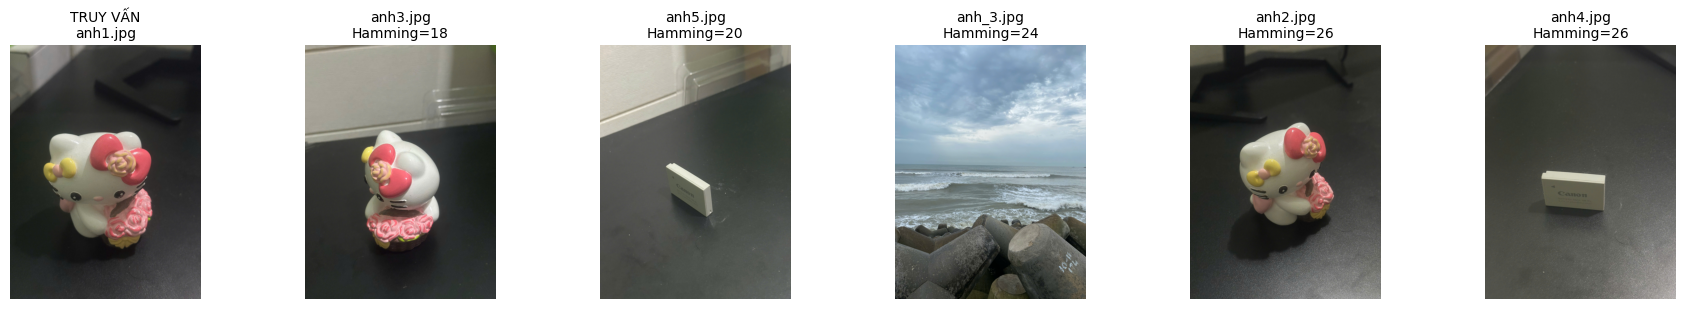

In [23]:
# MỤC 8: ỨNG DỤNG TÌM KIẾM ẢNH GẦN NHẤT
# Sắp xếp ảnh theo khoảng cách Hamming tăng dần so với ảnh truy vấn.
query_name = similar_paths[0].name
ranking = sorted(
    [(name, hamming_distance(hashes[query_name], value)) for name, value in hashes.items() if name != query_name],
    key=lambda item: (item[1], item[0]),
)
top_k = min(5, len(ranking))
ranking = ranking[:top_k]
print("[INPUT] Ảnh truy vấn:", query_name)
for rank, (name, distance) in enumerate(ranking, 1):
    print(f"[OUTPUT] {rank}. {name:30s} Hamming={distance}")

fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3.2), squeeze=False)
axes = axes.flat
axes[0].imshow(images[query_name])
axes[0].set_title("TRUY VẤN\n" + query_name)
axes[0].axis("off")
for ax, (name, distance) in zip(axes[1:], ranking):
    ax.imshow(images[name])
    ax.set_title(f"{name}\nHamming={distance}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wavelet_hash_retrieval.png", dpi=150, bbox_inches="tight")
print("[NHẬN XÉT] Ảnh tương tự đúng nên xuất hiện ở các vị trí đầu với Hamming nhỏ.")


## 9. Kết luận

- **Input:** hai nhóm ảnh do bạn tự chuẩn bị.
- **Xử lý:** ảnh → dải tần thấp Wavelet → mã 64 bit → khoảng cách Hamming.
- **Output:** khoảng cách từng cặp, ngưỡng phân loại, các chỉ số đánh giá, ROC, ma trận nhầm lẫn và kết quả tìm kiếm.
- Nếu ảnh bị crop mạnh, che khuất hoặc đổi phối cảnh, Wavelet Hash có thể kém ổn định; khi đó nên thử SIFT/ORB + matching + RANSAC.

**Bài tập:** thêm ảnh nén JPEG, ảnh xoay mạnh hoặc ảnh đổi sáng vào `tuong_tu`, chạy lại toàn bộ và giải thích vì sao Hamming thay đổi.
